## Results Analysis

The results follow this order: time and feasibility; presets; execution type; gradient method; randomness; scaling; and implementation/packing validation.

Unless stated otherwise, quality figures use completed 1000-epoch simulator runs. CPU/GPU copies of the same scientific run are collapsed for quality analysis, while device remains explicit in timing. Comparison figures show evaluation only, with faint run traces and median/IQR shadows showing variation across seeds. The sole exception is the preset learning-dynamics comparison in Section 2.1, which retains the joined blue generator-loss, red discriminator-loss, and orange evaluation layout.


In [5]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
qgan_dir = next(
    (
        candidate
        for root in (cwd, *cwd.parents)
        for candidate in (root, root / "qgan")
        if (candidate / "src" / "qgan_v2").is_dir()
    ),
    None,
)
if qgan_dir is None:
    raise RuntimeError("Could not find the qgan project directory.")

src_path = qgan_dir / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
repo_root = qgan_dir.parent
print({"qgan_dir": qgan_dir, "repo_root": repo_root})

{'qgan_dir': PosixPath('/home/benat/Qiskit-IBM/qgan'), 'repo_root': PosixPath('/home/benat/Qiskit-IBM')}


In [6]:
from qgan_v2.analysis import ResultsAnalysis

### Analysis setup and figure export

Set `EXPORT_FIGURES = True` to save only 300-dpi PNG files under `qgan/figures/results_analysis`. Each subsection keeps its scientific filters and comparison choices visible in the notebook; reusable loading and plotting mechanics live in `qgan_v2.analysis`. KL divergence (`base`) and image-gradient scores (`ang`/`amp`) are faceted rather than pooled because their scales are not comparable.

Summary panels pair the minimum recorded evaluation with **Average Best Evaluation So Far**: compute the cumulative minimum separately for each run, then average it over its recorded epochs. Lower values reward reaching better evaluations earlier; subsequent deterioration does not erase an achievement. This produces one raw score per run, without additional learning curves or a target threshold. It combines timing and quality rather than establishing convergence or stability. Compare the same metric over a common epoch budget and recording cadence; short hardware cases use their own matched horizons. Sampling noise can make either best-based statistic optimistic. Epoch indices remain available only to identify selected checkpoints.


In [7]:
EXPORT_FIGURES = True
GPU_MODEL_LABEL = "RTX6000"  # Change if another GPU timing battery is loaded.
PRESET_ORDER = ("base", "ang", "amp")
GRADIENT_ORDER = ("PSR", "REG", "SPSA")

analysis = ResultsAnalysis.load(
    qgan_dir,
    export_figures=EXPORT_FIGURES,
    gpu_model_label=GPU_MODEL_LABEL,
)
analysis.results.summary()

{'raw_learn/case-study_configs': 717,
 'completed_deduplicated_simulator_runs': 388,
 'completed_five_epoch_timing_runs': 226,
 'usable_real_hardware_runs': 2,
 'usable_implementation_validation_runs': 8,
 'evaluation_families': {'gradient': 236, 'kl': 152}}

### 1. Timing and Experimental Feasibility

Measured timing comes first so the reader understands which experiments were computationally practical before interpreting model quality. The section uses the two complementary measured-time views needed for that purpose, then records the experimental limits.


#### 1.1 Matched device runtime

The completed five-epoch timing battery is first compared through matched workloads. Median time per epoch is used because it is less sensitive to a slow initialization epoch.

One figure per preset groups runs by qubit count and gradient method. Paired noiseless and noisy panels show only groups with observed data and use a logarithmic time axis. Vertically aligned markers compare CPU/1, CPU/4, GPU, and available Real-QPU measurements, with direct speed-up labels relative to CPU/1; single-environment measurements remain visible without a speed-up label.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01a_base_matched_environment_runtime.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01a_base_matched_environment_runtime.png


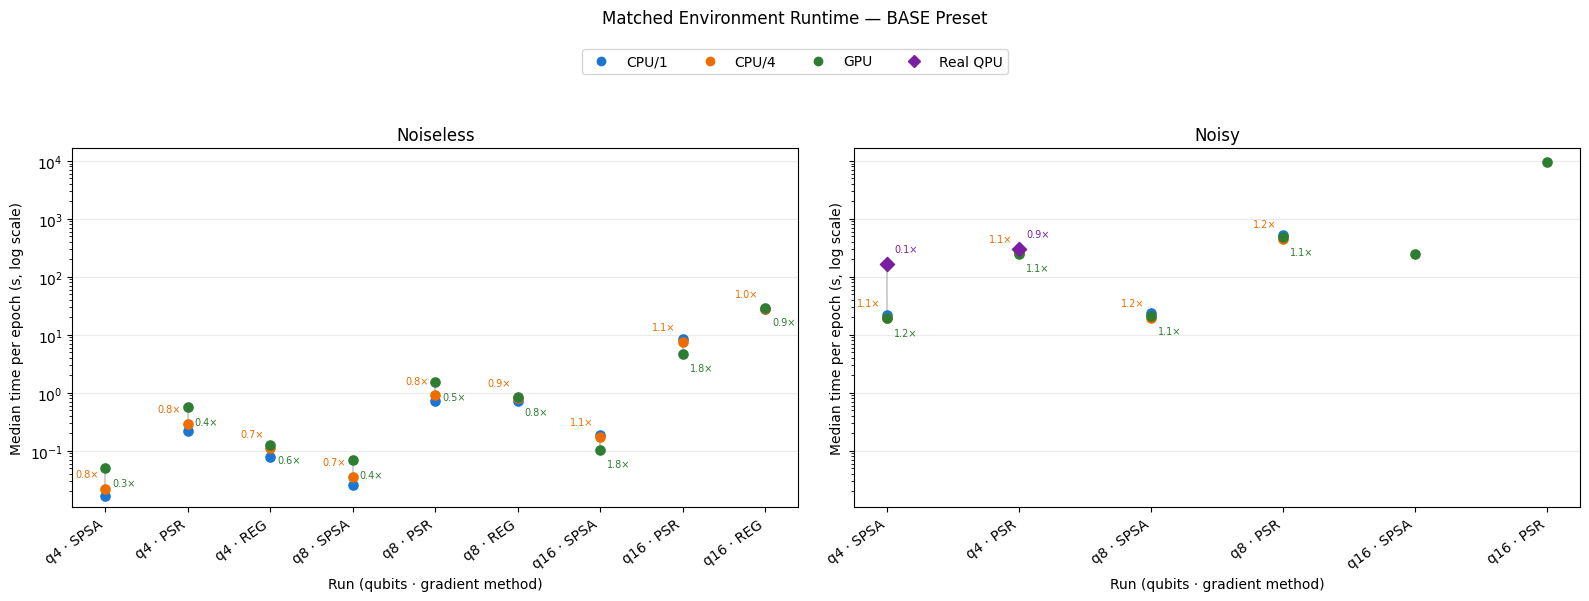

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01a_ang_matched_environment_runtime.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01a_ang_matched_environment_runtime.png


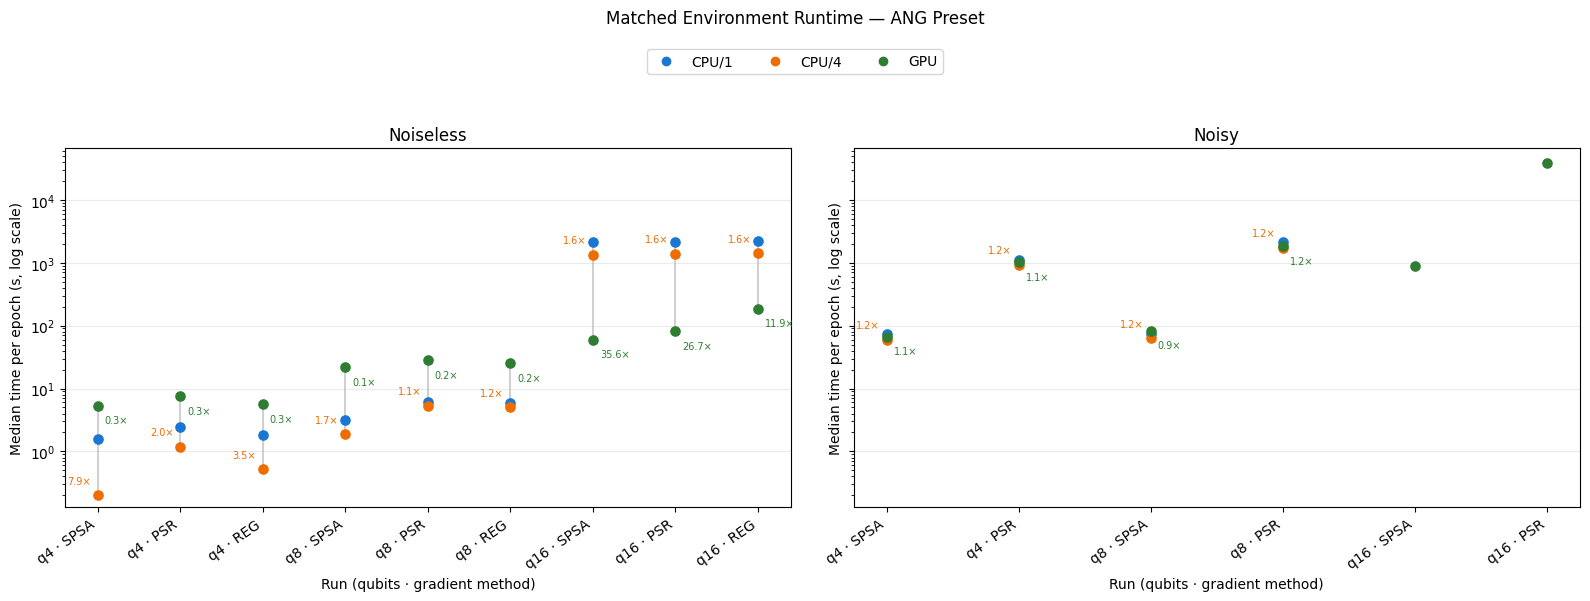

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01a_amp_matched_environment_runtime.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01a_amp_matched_environment_runtime.png


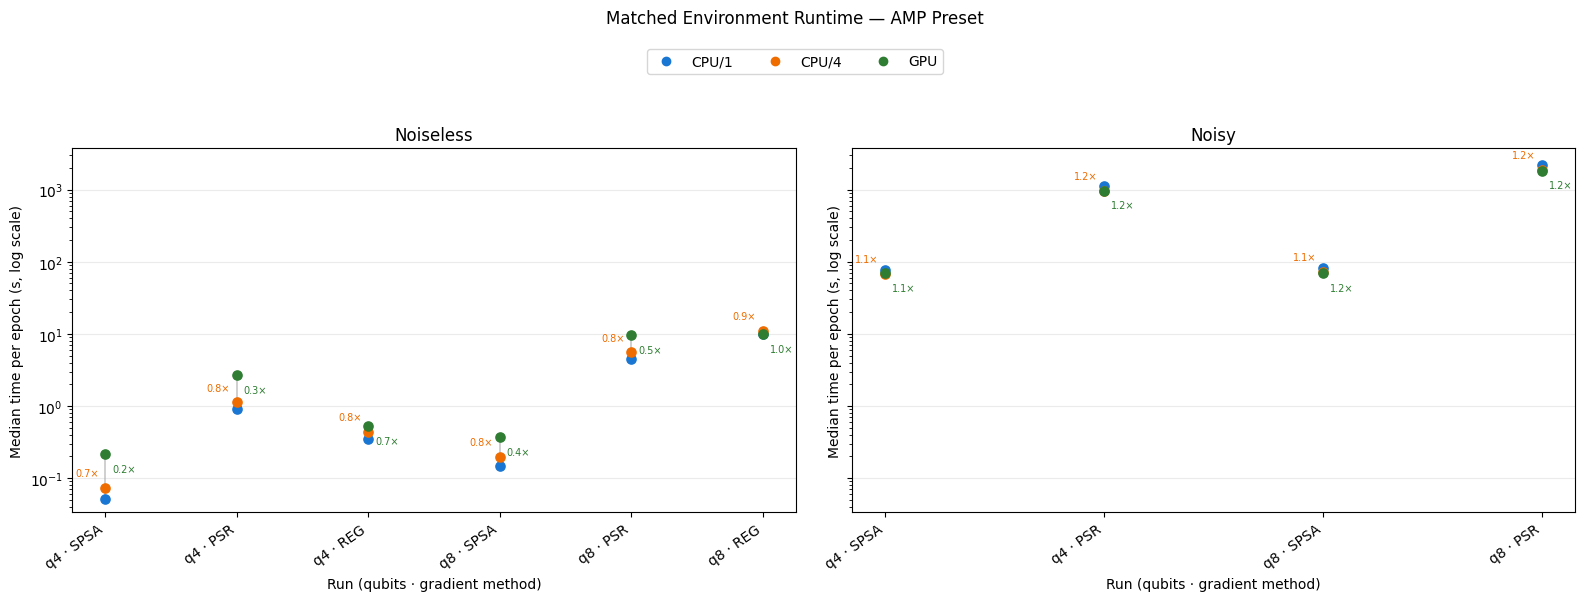

In [4]:
matched_timing_runs = {
    preset: analysis.matched_timing_comparison(preset=preset)
    for preset in PRESET_ORDER
}


The matched figures show that environment effects depend on preset, qubit count, and gradient method rather than producing one universally fastest platform. Real-QPU timings appear beside the corresponding noisy q4 groups where available.


#### 1.2 Epoch-time distributions

The second view retains the variation hidden by a single matched-run statistic. Here, `compare_by="randomness"` creates one panel for each available device and places rand0/rand1 on the x-axis while pooling eligible presets, execution types, qubit counts, and gradient methods. Each run median is a solid circle and its individual epoch times are faint shadow circles. Empty categories, their unused space, and entirely empty device panels are omitted; panel widths preserve a consistent category width. The default layout is a compact horizontal `1 × N`, with `layout=(rows, columns)` available when another arrangement is needed. Other scientific fields may be selected with `compare_by` or supplied as filters, while omitting `compare_by` retains the controlled single-configuration view. Epochs are repeated measurements within a run, not independent replicates.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.png


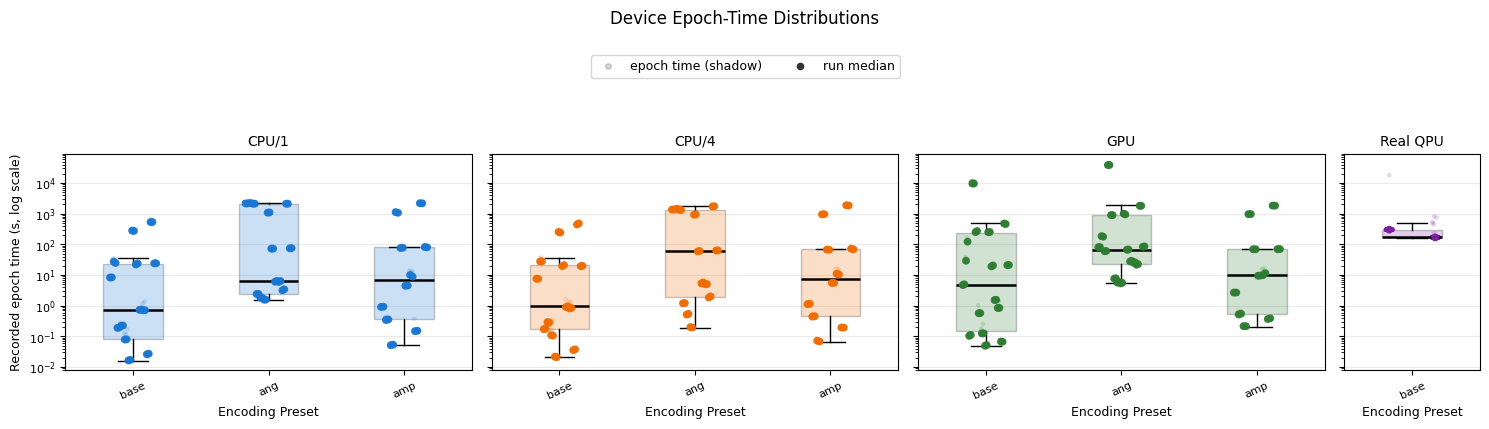

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.png


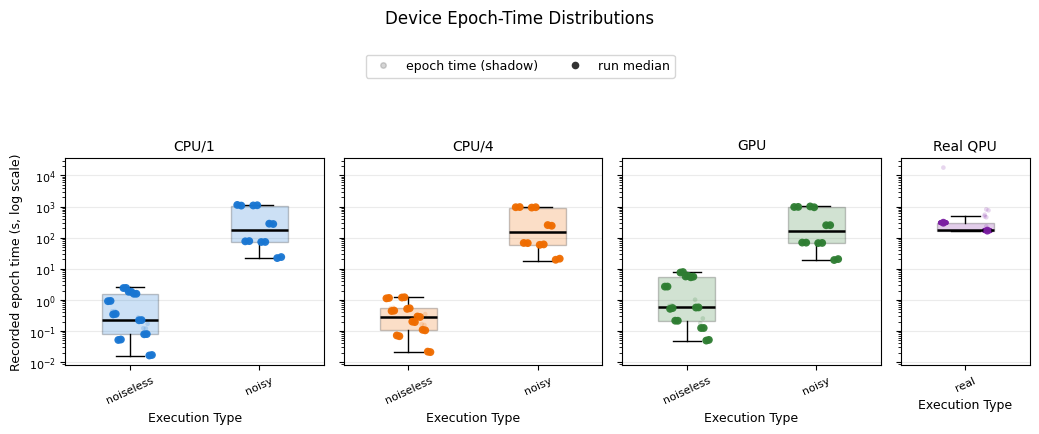

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.png


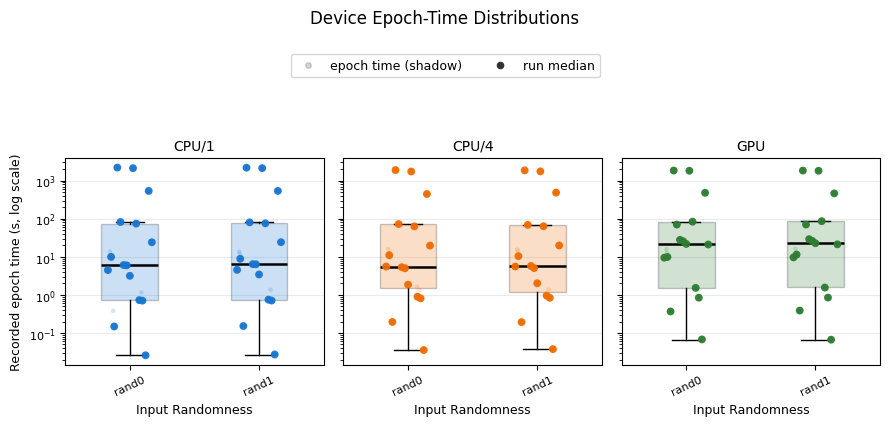

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.png


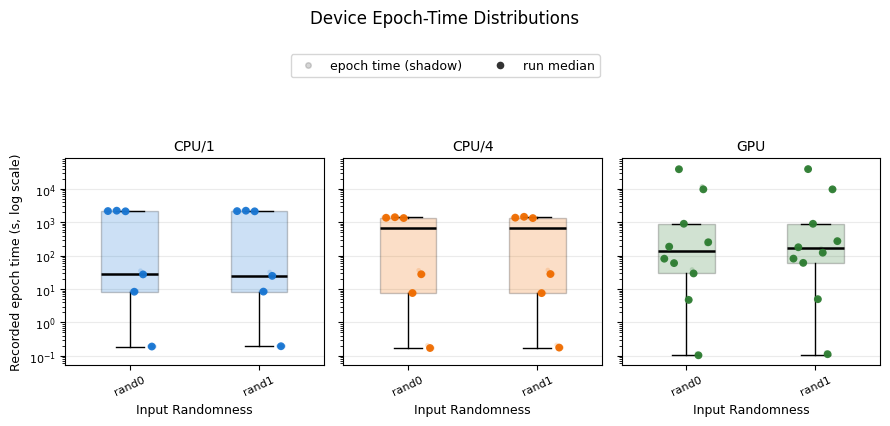

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01b_device_timing_distributions.png


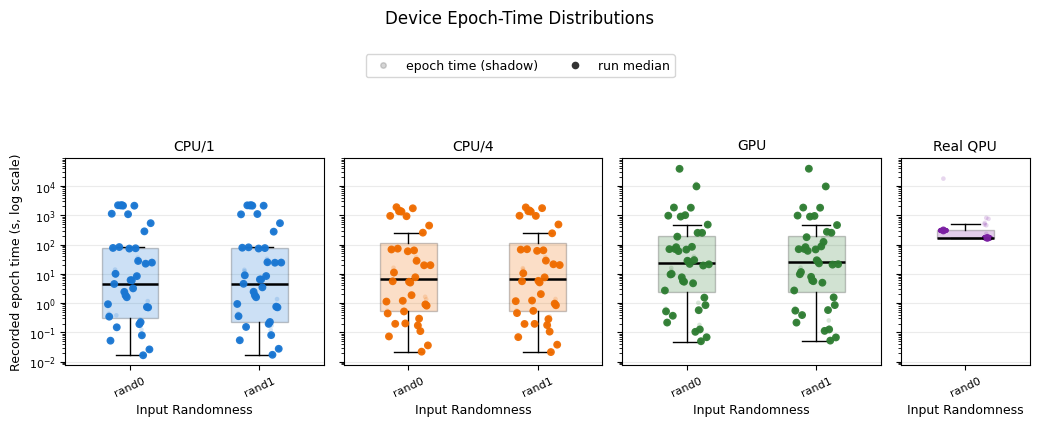

In [5]:
epoch_timing_runs = analysis.timing_distributions(compare_by="preset")

epoch_timing_runs = analysis.timing_distributions(n_qubits=(4), compare_by="execution_type")
epoch_timing_runs = analysis.timing_distributions(n_qubits=(8), compare_by="randomness")
epoch_timing_runs = analysis.timing_distributions(n_qubits=(16), compare_by="randomness")

epoch_timing_runs = analysis.timing_distributions(compare_by="randomness")


These panels reveal whether device-level timing differences are stable across epochs and runs or are driven by initialization and a small number of slow epochs. They also show the full rand0/rand1 timing evidence rather than restricting the comparison to one preset, execution type, qubit count, or gradient method.


#### 1.3 Experimental feasibility and limitations

This subsection records the known resource boundary for each omitted or unfinished experiment class. It deliberately excludes `fake_real`, which is an implementation-validation mode rather than a feasibility result. The completion matrix expands one selected learning dynamics battery (CPU or GPU, never both) and the CPU, GPU, and real-hardware timing batteries. For every requested config, the generated run directory is checked for `training_data.pth`; a run is complete only when its recorded epochs reach the battery config's `training.max_iterations`. The adjacent bars partition the matrix's incomplete requests by limitation, so their per-qubit totals match the incomplete counts in the matrix.

The categories distinguish time cost, unavailable real-hardware execution time, statevector transpilation limits, and CPU memory limits. They should be interpreted as experimental design constraints, not model-quality outcomes.

Replication is stated compactly here rather than repeated on every figure: the main matched simulator comparisons use three completed runs (seeds `0`, `1`, and `2`) per group. Any exception must report its actual completed-run count beside the corresponding result. The real-hardware comparison contains two short `qml_torch` case-study runs, while fake-real implementation validation uses one run (seed `0`) per implementation/packing configuration.


learning dynamics battery: train_learn_gpu.yaml
timing batteries: ['train_times_cpu.yaml', 'train_times_gpu.yaml', 'train_times_rh.yaml']


| Experiment | Limitation | Detail | Battery Reference |
| --- | --- | --- | --- |
| amplitude q16 | not transpilable | The statevector preparation circuit was too large/deep to transpile. | train_learn_cpu.yaml / train_learn_gpu.yaml |
| noisy q16 CPU timing | out of memory | The density-matrix timing jobs exceeded CPU memory. | train_times_cpu.yaml |
| real hardware q4 | execution time unavailable | Only runs with completed real-hardware timing checkpoints are available. | train_times_rh.yaml |
| noisy q4/q8 PSR learning dynamics | time-expensive | Parameter-shift noisy learning dynamics did not finish. | train_learn_cpu.yaml / train_learn_gpu.yaml |
| noisy q16 learning dynamics | time-expensive | Projected execution exceeded the available GPU allocation. | train_learn_gpu.yaml |

| Source | Execution Type | Requested | Complete | Not Complete |
| --- | --- | --- | --- | --- |
| learning dynamics | noiseless | 306 | 306 | 0 |
| learning dynamics | noisy | 96 | 37 | 59 |
| timing | noiseless | 96 | 96 | 0 |
| timing | noisy | 72 | 56 | 16 |
| timing | real | 9 | 2 | 7 |

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01d_experimental_limitations_and_feasibility.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/01d_experimental_limitations_and_feasibility.png


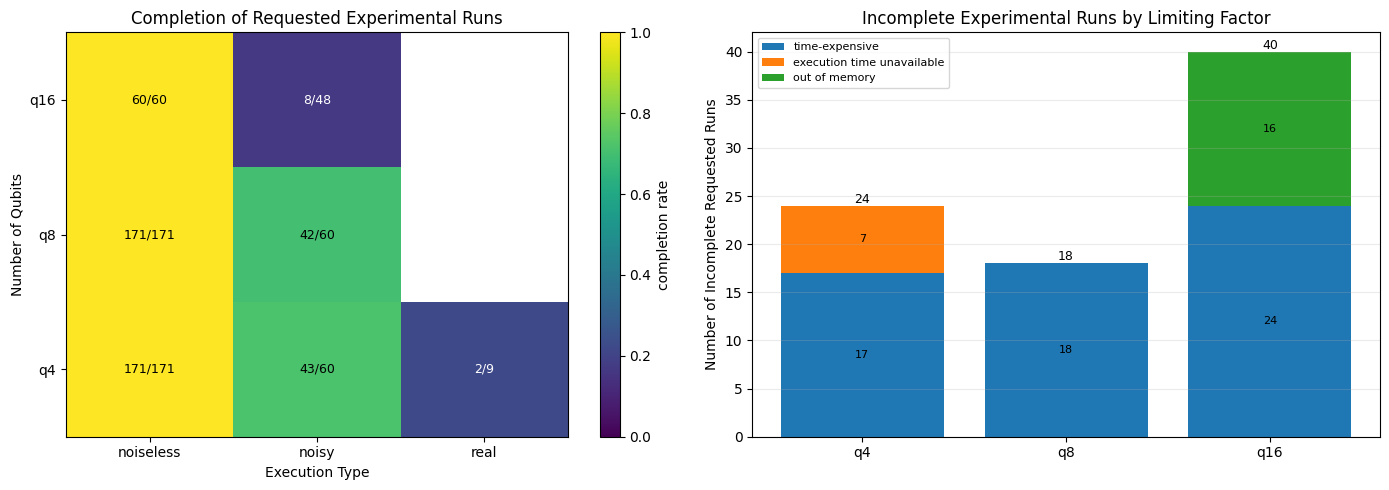

In [6]:
LEARN_BATTERY = qgan_dir / "configs/batteries/train/train_learn_gpu.yaml"
TIMING_BATTERIES = (
    qgan_dir / "configs/batteries/train/train_times_cpu.yaml",
    qgan_dir / "configs/batteries/train/train_times_gpu.yaml",
    qgan_dir / "configs/batteries/train/train_times_rh.yaml",
)

feasibility_results = analysis.feasibility(
    learn_battery=LEARN_BATTERY,
    timing_batteries=TIMING_BATTERIES,
)

### 2. Presets

This section establishes how the three data/encoding presets learn and then links the quantitative curves to generated outputs.


#### 2.1 Learning dynamics and best results

The comparison fixes noiseless PSR, `q4`, `rand0`, and seeds 0–2. Each preset has its own column because `base` minimizes KL divergence over a target probability distribution, while `ang` and `amp` use an image-gradient score.

Each preset column retains adversarial losses above evaluation: faint traces identify individual seed runs and solid lines with shadows give the median and IQR. The summary panels show best evaluation and average best evaluation so far; point color identifies the seed. This is the only subsection whose learning-dynamics graph includes generator and discriminator losses.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02a_preset_learning_dynamics.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02a_preset_learning_dynamics.png


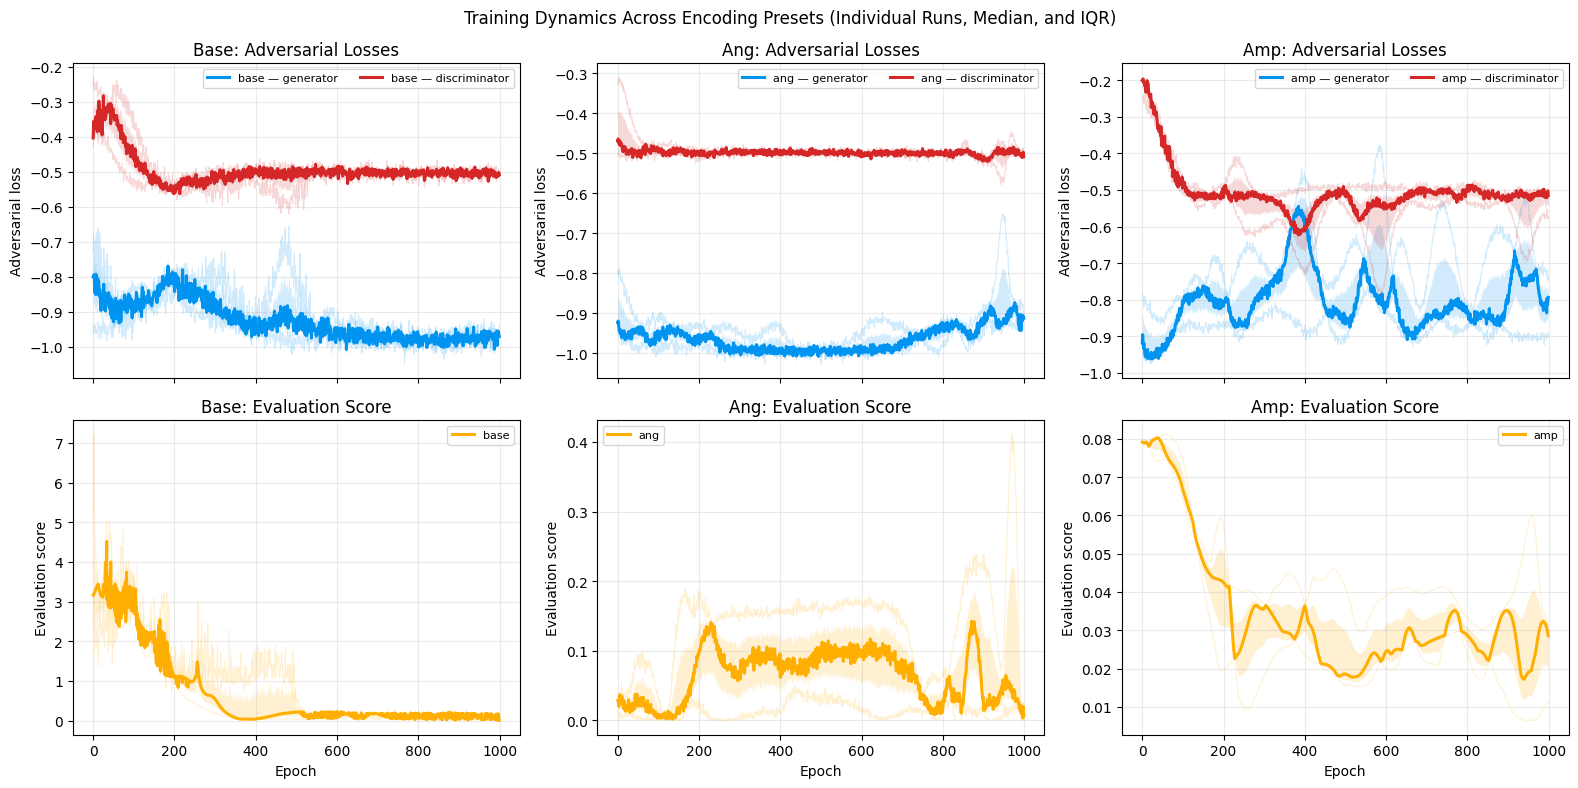

In [7]:
PRESET_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "PSR",
    "n_qubits": 4,
    "randomness": 0,
}
preset_runs = analysis.preset_learning_dynamics(
    filters=PRESET_FOCUS,
    presets=PRESET_ORDER,
)

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02b_preset_best_results.png


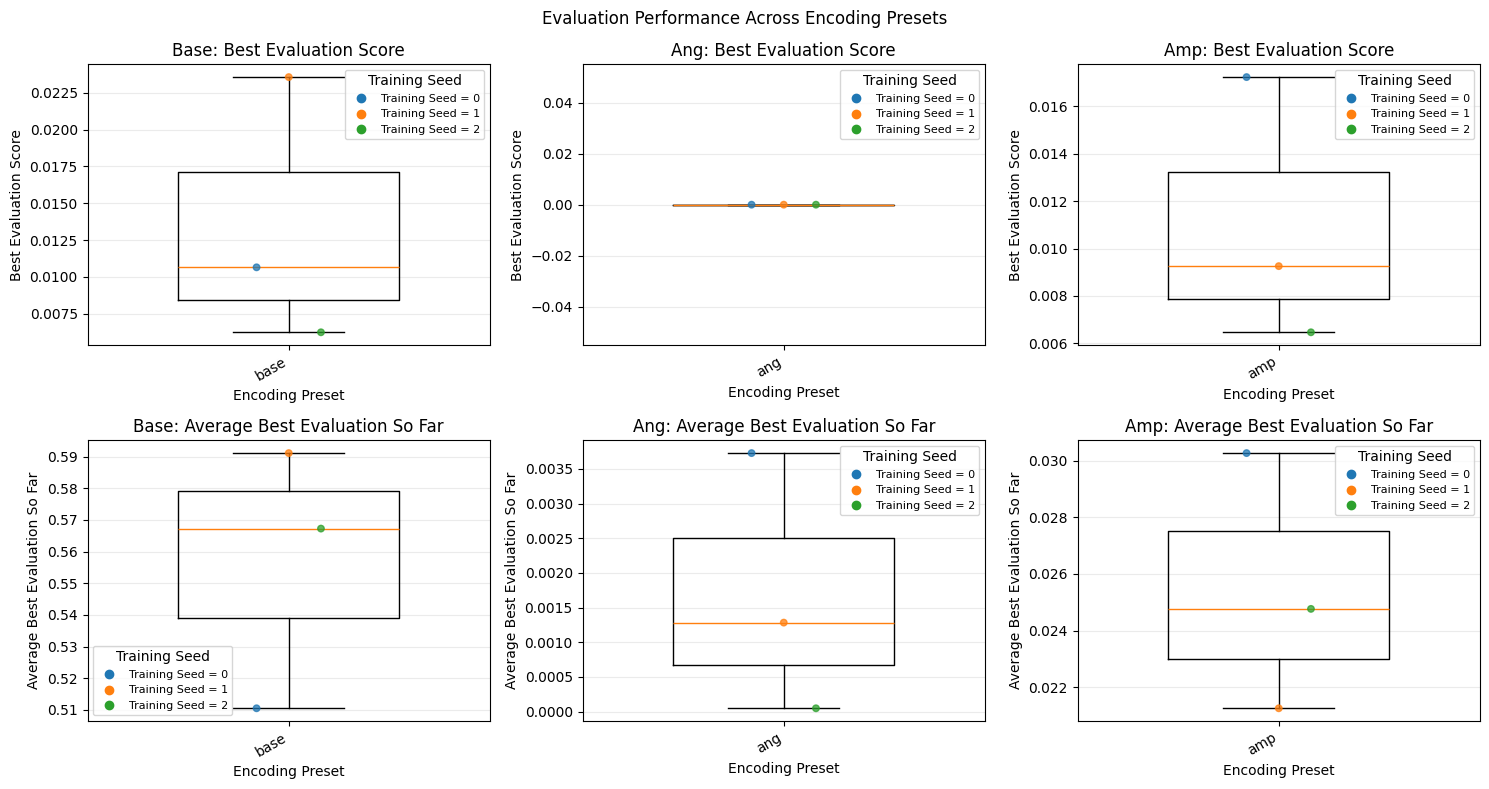

| Eval Method | Preset | Completed Runs | Seeds | Median Best Eval | Q25 Best Eval | Q75 Best Eval | Median Average Best So Far Eval |
| --- | --- | --- | --- | --- | --- | --- | --- |
| gradient | amp | 3 | (0, 1, 2) | 0.009258 | 0.007863 | 0.01324 | 0.02477 |
| gradient | ang | 3 | (0, 1, 2) | 0 | -0 | -0 | 0.001283 |
| kl | base | 3 | (0, 1, 2) | 0.01065 | 0.008448 | 0.01711 | 0.5673 |

In [8]:
preset_performance = analysis.preset_best_results(
    preset_runs,
    presets=PRESET_ORDER,
)

#### 2.2 Initial, last, best, and target outputs

The gradient method, randomness level, and training seed for the displayed noiseless `q4` runs can be selected explicitly below. The defaults match subsection 2.1: PSR, `rand0`, and seed 0. The initial, final-checkpoint, best-checkpoint, and target outputs are rendered together in one `1 × 4` row for each preset, making the full qualitative change and any regression after the optimum directly visible. `QUALITATIVE_RANDOM_SEED` in the following cell controls output sampling and is separate from the selected training seed.


In [9]:
OUTPUT_GRADIENT_METHOD = "PSR"
OUTPUT_RANDOMNESS = 0
OUTPUT_SEED = 0

OUTPUT_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "n_qubits": 4,
    "gradient_method": OUTPUT_GRADIENT_METHOD,
    "randomness": OUTPUT_RANDOMNESS,
    "seed": OUTPUT_SEED,
}
preset_output_manifest = analysis.select_preset_outputs(
    filters=OUTPUT_FOCUS,
    presets=PRESET_ORDER,
    gradient_priority=GRADIENT_ORDER,
)

| Preset | Run Id | Gradient Method | Randomness | Seed | Evaluation Metric | Best Eval | Average Best So Far Eval | Epoch Of Best Eval | Last Eval | Config File |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| base | base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 | PSR | 0 | 0 | kl | 0.01065 | 0.5105 | 999 | 0.01065 | /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml |
| ang | ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 | PSR | 0 | 0 | gradient | -0 | 0.003727 | 994 | -0 | /home/benat/Qiskit-IBM/qgan/data/train/ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml |
| amp | amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 | PSR | 0 | 0 | gradient | 0.01723 | 0.03026 | 938 | 0.02856 | /home/benat/Qiskit-IBM/qgan/data/train/amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml |

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02c_base_initial_last_best_target.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02c_base_initial_last_best_target.png


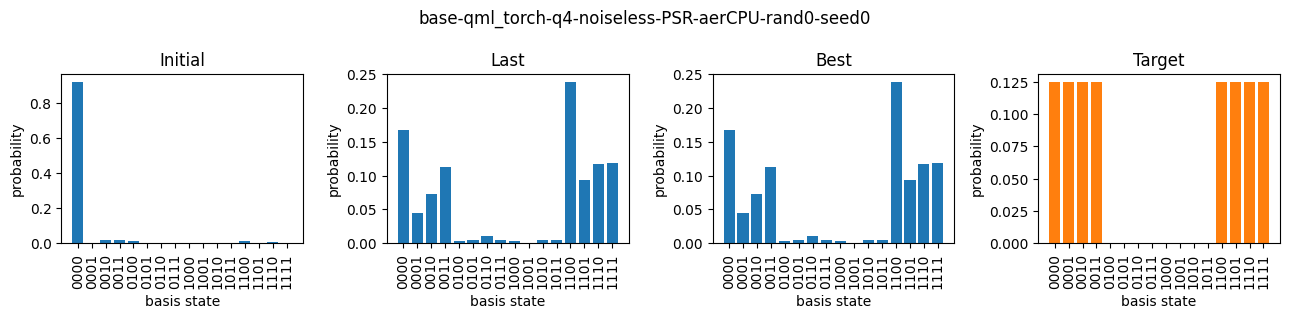

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02c_ang_initial_last_best_target.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02c_ang_initial_last_best_target.png


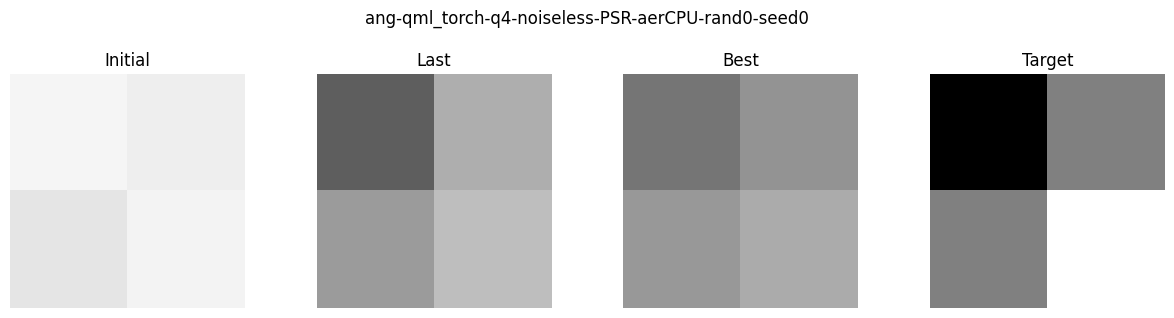

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02c_amp_initial_last_best_target.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/02c_amp_initial_last_best_target.png


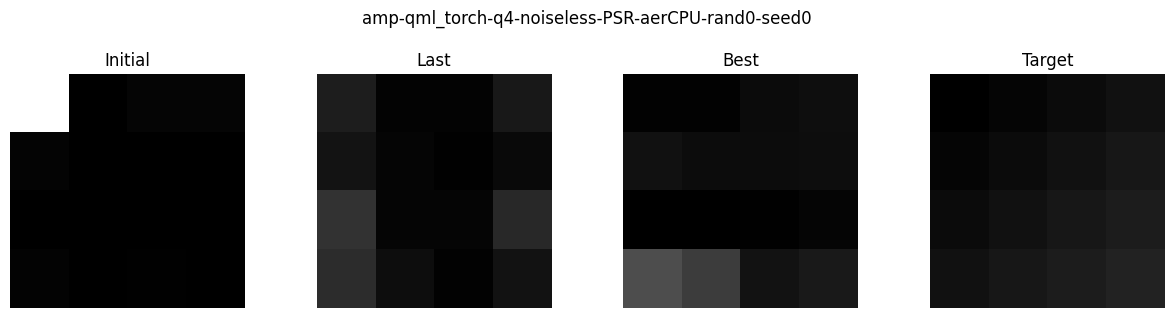

| Preset | Run Id | Config File | Execution Type | Parameter Sets | Random Seed | Evaluations |
| --- | --- | --- | --- | --- | --- | --- |
| base | base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 | /home/benat/Qiskit-IBM/qgan/data/train/base-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml | noiseless | ('initial', 'last', 'best') | 0 | {'initial': {'score': nan, 'epoch': None}, 'last': {'score': 0.010651926471313883, 'epoch': 999}, 'best': {'score': 0.010651926471313883, 'epoch': 999}} |
| ang | ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 | /home/benat/Qiskit-IBM/qgan/data/train/ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml | noiseless | ('initial', 'last', 'best') | 0 | {'initial': {'score': nan, 'epoch': None}, 'last': {'score': -0.0, 'epoch': 999}, 'best': {'score': -0.0, 'epoch': 994}} |
| amp | amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0 | /home/benat/Qiskit-IBM/qgan/data/train/amp-qml_torch-q4-noiseless-PSR-aerCPU-rand0-seed0/config.yaml | noiseless | ('initial', 'last', 'best') | 0 | {'initial': {'score': nan, 'epoch': None}, 'last': {'score': 0.028564980258291142, 'epoch': 999}, 'best': {'score': 0.01722801708234104, 'epoch': 938}} |

In [10]:
RENDER_PRESET_OUTPUTS = True
QUALITATIVE_RANDOM_SEED = 0

if RENDER_PRESET_OUTPUTS:
    rendered_output_manifest = analysis.render_preset_outputs(
        random_seed=QUALITATIVE_RANDOM_SEED
    )
else:
    print("Set RENDER_PRESET_OUTPUTS = True to create the four-panel output figures.")

### 3. Execution-Type Comparison

Simulation provides the replicated comparison; the much smaller real-hardware sample is separated so its evidential limits remain explicit.


#### 3.1 Noiseless versus noisy simulation

This comparison uses matched `q4`, SPSA, `rand0`, seeds 0–2. Each preset remains in its own metric column. Learning curves show evaluation only; summaries retain best evaluation and average best evaluation so far.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/03a_noiseless_noisy_dynamics.pdf
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/03a_noiseless_noisy_dynamics.png


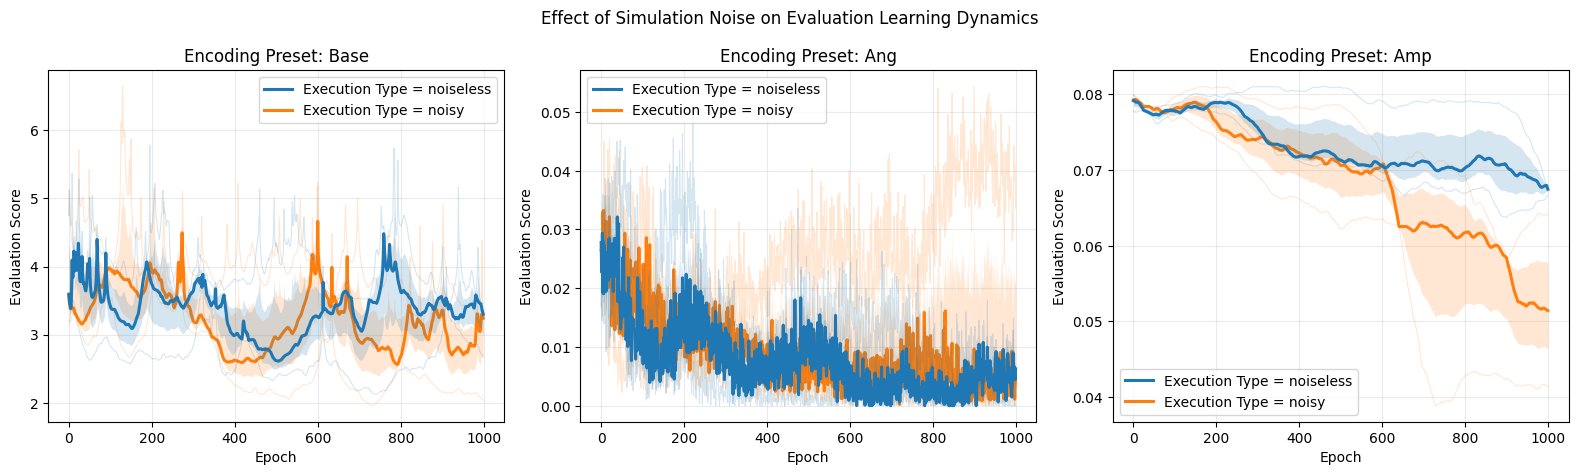

In [11]:
SIMULATION_EXECUTION_FOCUS = {
    "implementation": "qml_torch",
    "gradient_method": "SPSA",
    "n_qubits": 4,
    "randomness": 0,
    "execution_type": ("noiseless", "noisy"),
}
simulation_execution_runs = analysis.simulation_execution_dynamics(
    filters=SIMULATION_EXECUTION_FOCUS,
    presets=PRESET_ORDER,
)

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/03b_noiseless_noisy_best_results.png
Out[1]: 
[RunResult(path=PosixPath('/home/benat/Qiskit-IBM/qgan/data/train/amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0'), config={'implementation': {'name': 'qml_torch', 'discriminator_packing': 'separate'}, 'run': {'id': 'amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0', 'label': None, 'data_path': 'qgan/data/train', 'seed': 0, 'device': 'CPU'}, 'experiment': {'preset': 'amp', 'execution_type': 'noiseless', 'n_qubits': 4, 'gradient_method': 'SPSA'}, 'training': {'max_iterations': 1000, 'gen_iterations': 1, 'disc_iterations': 1, 'init_scale': 0.1, 'learning_rate': 0.005, 'print_every': 10, 'checkpoint_every': 10}, 'dataset': {'id': 'generated_gradients-total_pixels16', 'reset': False, 'type': 'classical', 'source': 'generated_gradients', 'parameters': {'total_pixels': 16}}, 'circuits': {'reset': False, 'generator': 'real_amplitudes', 'discriminator': 'efficient_su2'}, 'backend': {

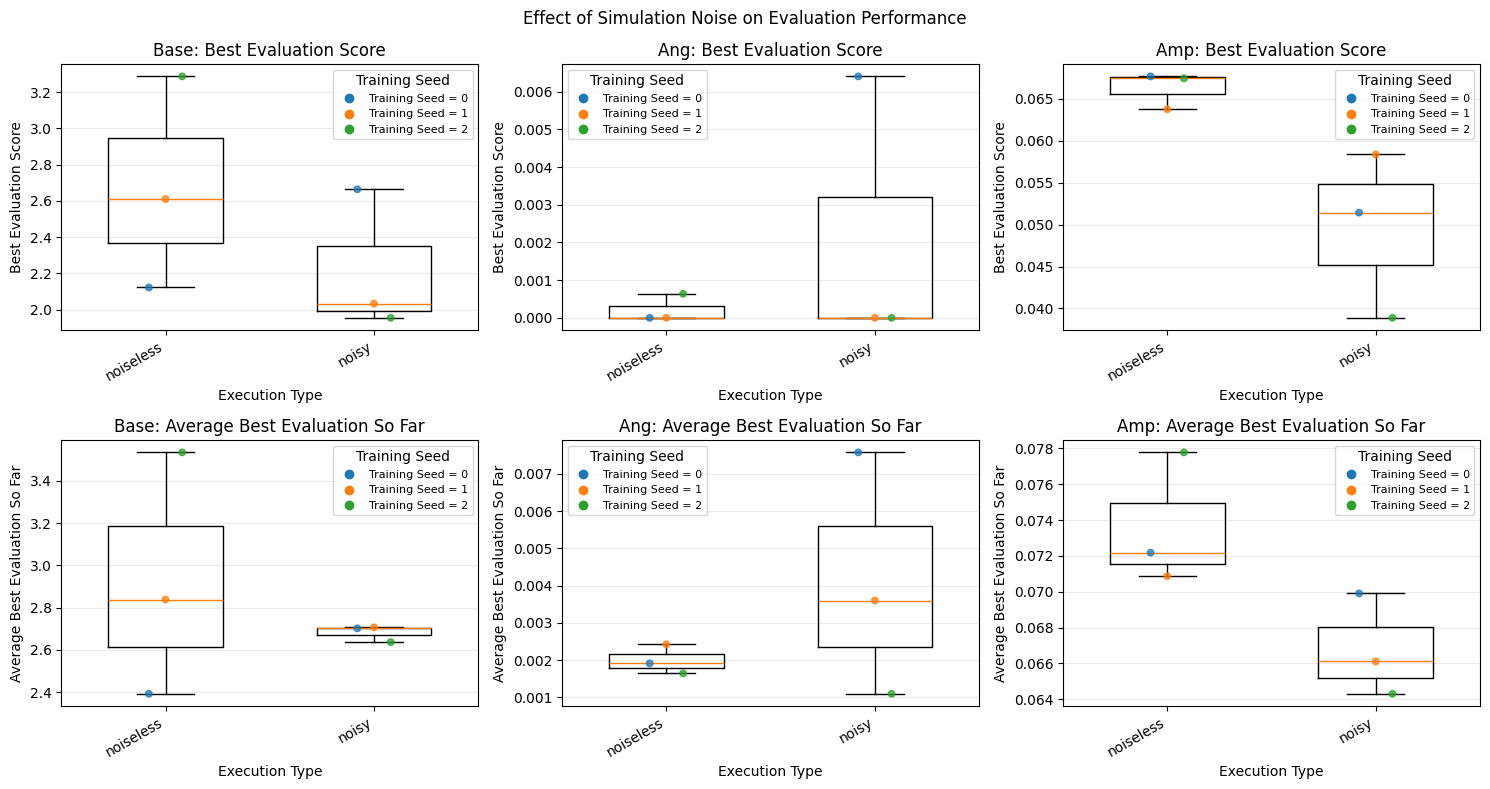

[RunResult(path=PosixPath('/home/benat/Qiskit-IBM/qgan/data/train/amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0'), config={'implementation': {'name': 'qml_torch', 'discriminator_packing': 'separate'}, 'run': {'id': 'amp-qml_torch-q4-noiseless-SPSA-aerCPU-rand0-seed0', 'label': None, 'data_path': 'qgan/data/train', 'seed': 0, 'device': 'CPU'}, 'experiment': {'preset': 'amp', 'execution_type': 'noiseless', 'n_qubits': 4, 'gradient_method': 'SPSA'}, 'training': {'max_iterations': 1000, 'gen_iterations': 1, 'disc_iterations': 1, 'init_scale': 0.1, 'learning_rate': 0.005, 'print_every': 10, 'checkpoint_every': 10}, 'dataset': {'id': 'generated_gradients-total_pixels16', 'reset': False, 'type': 'classical', 'source': 'generated_gradients', 'parameters': {'total_pixels': 16}}, 'circuits': {'reset': False, 'generator': 'real_amplitudes', 'discriminator': 'efficient_su2'}, 'backend': {'reset': False, 'save_backend_file': False, 'precision': 0.015625, 'transpilation': {'optimization_level':

In [12]:
analysis.simulation_execution_best_results(
    simulation_execution_runs,
    presets=PRESET_ORDER,
)

#### 3.2 Noiseless, noisy, and real hardware

The two available real-QPU runs are compared against matching simulator runs truncated to the same observed epoch budget. This is behavioral evidence for those runs, not a replicated estimate of hardware performance.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/03c_real_hardware_dynamics.png
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/03d_real_hardware_best_results.png


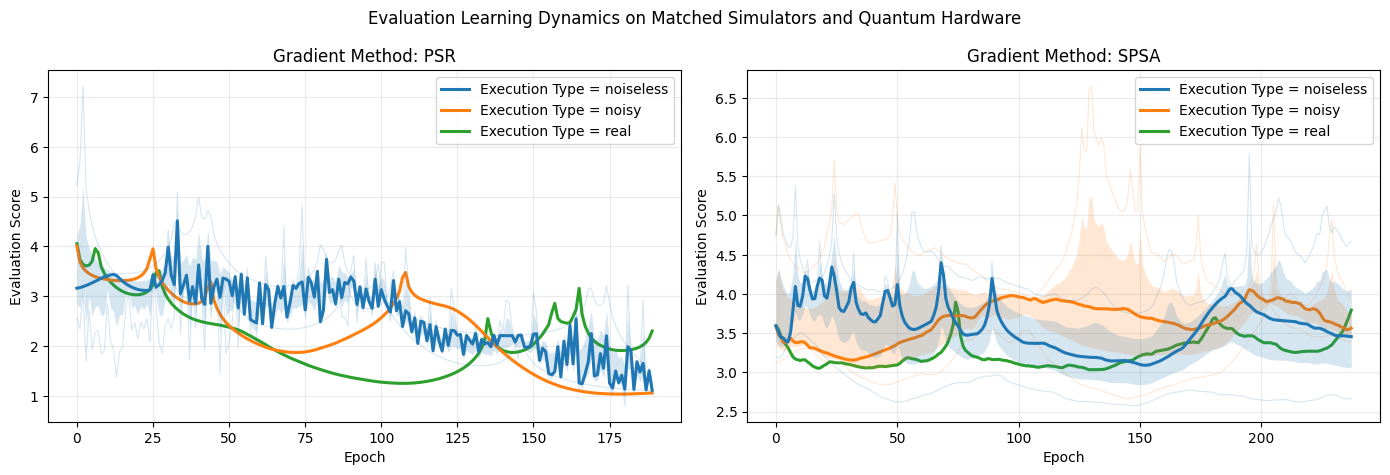

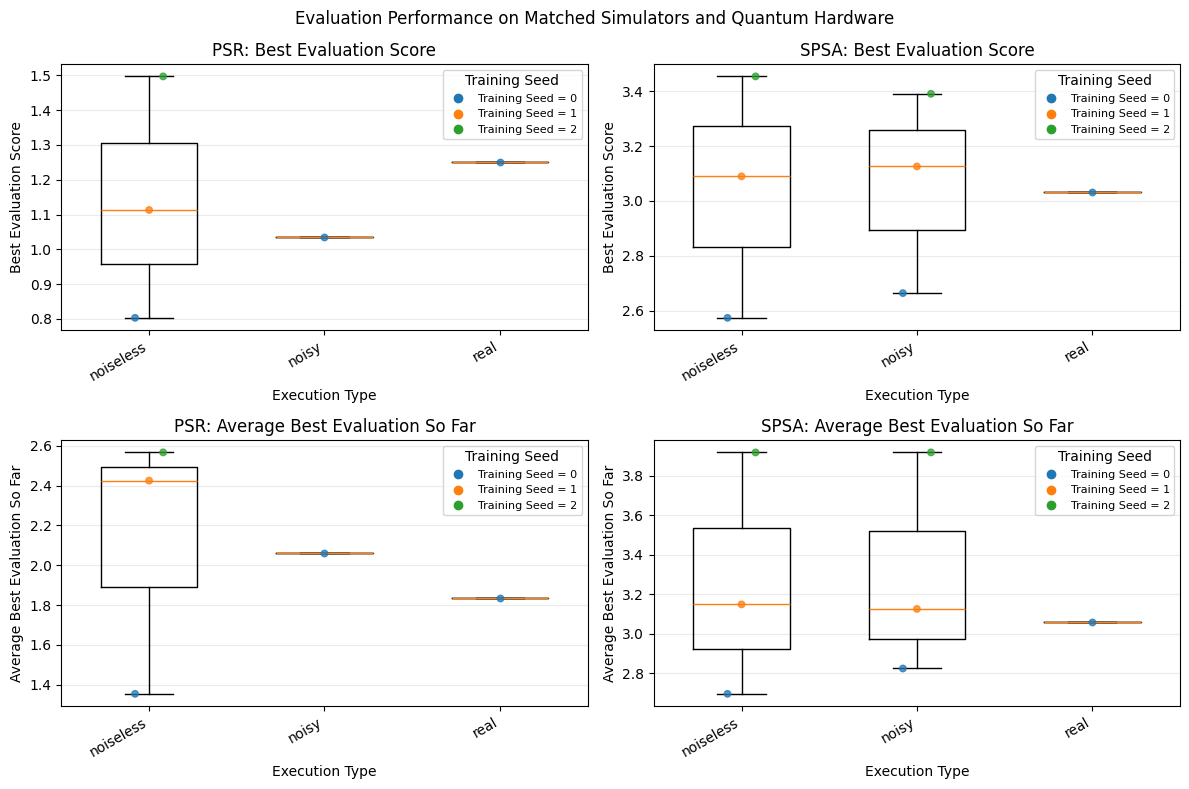

| Run Id | Gradient Method | Completed Epochs | Best Eval | Average Best So Far Eval | Median Time Per Epoch |
| --- | --- | --- | --- | --- | --- |
| base-qml_torch-q4-real-PSR-aerCPU-rand0-seed0 | PSR | 190 | 1.252 | 1.836 | 302.9 |
| base-qml_torch-q4-real-SPSA-aerCPU-rand0-seed0 | SPSA | 238 | 3.033 | 3.058 | 168.7 |

In [13]:
REAL_HARDWARE_FOCUS = {
    "execution_type": "real",
    "implementation": "qml_torch",
    "preset": "base",
    "n_qubits": 4,
    "randomness": 0,
}
hardware_cases = analysis.real_hardware_comparison(
    filters=REAL_HARDWARE_FOCUS,
    eval_method="kl",
)

### 4. Gradient Method Comparison

SPSA, PSR, and REG are compared with preset, execution type, qubits, randomness, and evaluation metric fixed. Timing is absent here because it is analyzed in Section 1.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/04a_gradient_dynamics.png


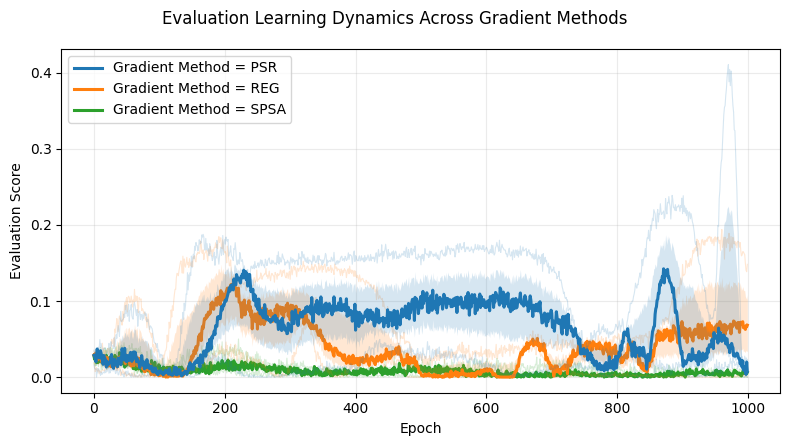

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/04b_gradient_best_results.png


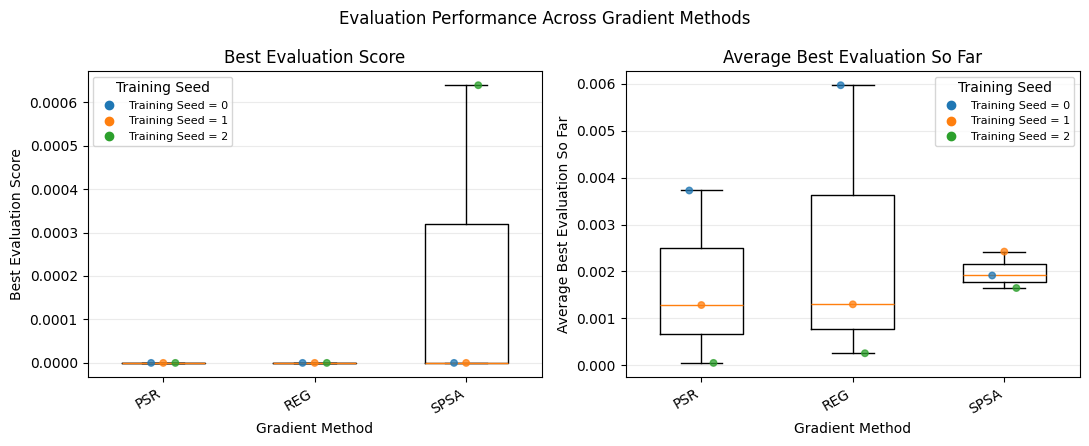

In [10]:
GRADIENT_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "n_qubits": 4,
    "randomness": 0,
    "eval_method": "gradient",
}
gradient_runs = analysis.gradient_comparison(filters=GRADIENT_FOCUS)

### 5. Randomness Effect

Randomness is first studied as a complete five-level sweep, followed by fresh output generation from a selected run and then a wider matched `rand0`/`rand1` comparison.


#### 5.1 Complete five-level randomness sweep

All three presets have complete sweeps containing all five values (`0`, `0.1`, `0.25`, `0.5`, `1`) for seeds 0–2. Select `base`, `ang`, or `amp` with `RANDOMNESS_PRESET`, select `PSR`, `REG`, or `SPSA` with `RANDOMNESS_GRADIENT_METHOD`, and use `RANDOMNESS_SWEEP_INDEX` to choose between the q4 and q8 complete sweeps. Evaluation step volatility is the median absolute change between consecutive evaluation scores; larger values indicate a more erratic learning trajectory.


complete five-level × three-seed sweeps: 2
selected sweep: {'preset': 'ang', 'gradient_method': 'PSR', 'n_qubits': 4, 'execution_type': 'noiseless', 'eval_method': 'gradient'}
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/05a_randomness_complete_dynamics.png
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/05b_randomness_complete_best_and_volatility.png


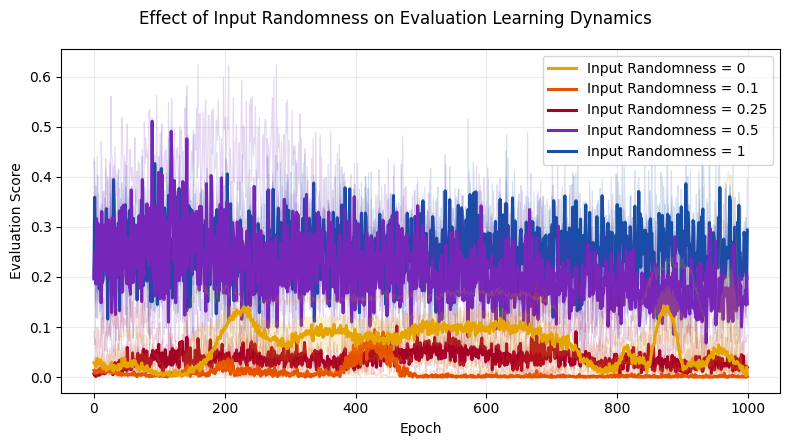

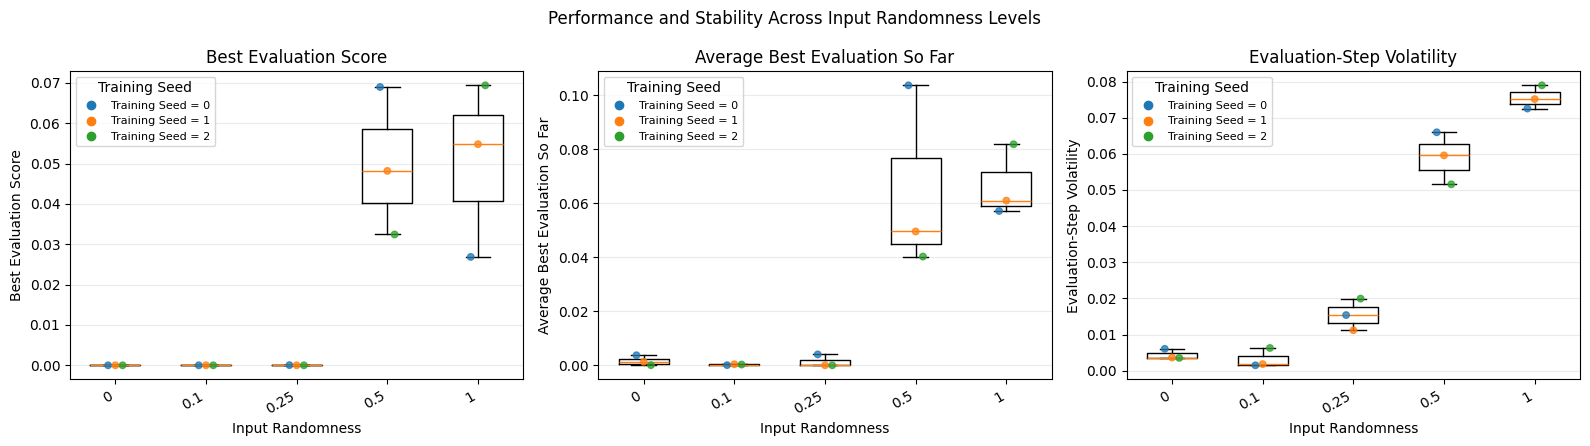

In [15]:
RANDOMNESS_LEVELS = (0, 0.1, 0.25, 0.5, 1)
RANDOMNESS_SEEDS = (0, 1, 2)
RANDOMNESS_PRESET = "ang"
RANDOMNESS_GRADIENT_METHOD = "PSR"
RANDOMNESS_SWEEP_INDEX = 0

randomness_main = analysis.randomness_sweep(
    filters={
        "preset": RANDOMNESS_PRESET,
        "gradient_method": RANDOMNESS_GRADIENT_METHOD,
    },
    levels=RANDOMNESS_LEVELS,
    required_seeds=RANDOMNESS_SEEDS,
    sweep_index=RANDOMNESS_SWEEP_INDEX,
)

#### 5.2 Generate new samples from a selected run

Choose a preset, randomness level, training seed, and number of outputs below. The selected completed noiseless `q4` PSR run is evaluated with its best generator parameters, and every generated output is shown beside the target in one figure. `RANDOMNESS_OUTPUT_INPUT_SEED = None` draws a new random input for every output; set it to an integer for reproducible consecutive input seeds. For `rand0`, the randomizer circuit is disabled, so multiple outputs are identical because no random vector is applied.


| Preset | Gradient Method | N Qubits | Randomness | Training Seed | Random Input Applied | Run Id | Config File | Execution Type | Parameter Set | Random Seed | Input Seeds | Num Outputs | Evaluation Score | Evaluation Epoch |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ang | PSR | 4 | 0.25 | 0 | True | ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0.25-seed0 | /home/benat/Qiskit-IBM/qgan/data/train/ang-qml_torch-q4-noiseless-PSR-aerCPU-rand0.25-seed0/config.yaml | noiseless | best | — | (None, None, None, None) | 4 | 4.352e-05 | 991 |

saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/05c_ang_rand0p25_seed0_best_output.png


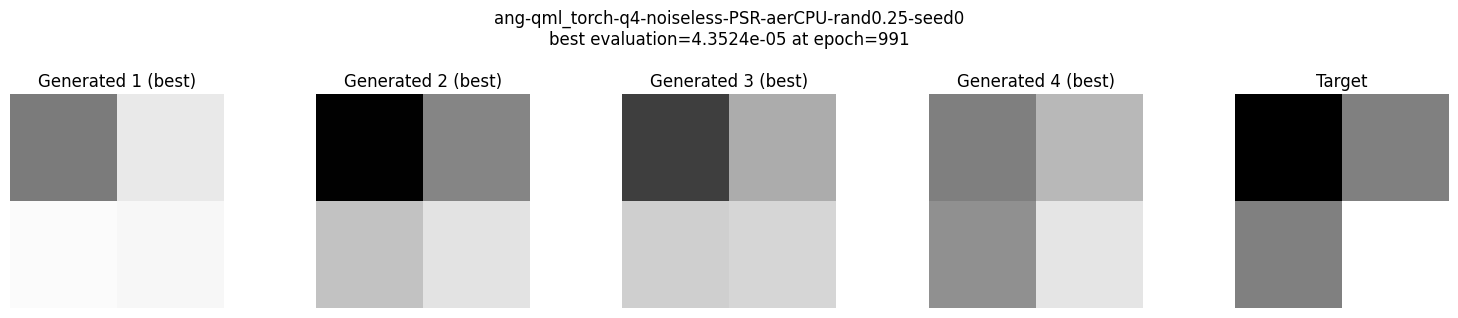

In [12]:
RANDOMNESS_OUTPUT_PRESET = "ang"
RANDOMNESS_OUTPUT_LEVEL = 0.25
RANDOMNESS_OUTPUT_TRAINING_SEED = 0
RANDOMNESS_OUTPUT_INPUT_SEED = None
RANDOMNESS_OUTPUT_COUNT = 4

RANDOMNESS_OUTPUT_FOCUS = {
    "preset": RANDOMNESS_OUTPUT_PRESET,
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "PSR",
    "n_qubits": 4,
    "randomness": RANDOMNESS_OUTPUT_LEVEL,
    "seed": RANDOMNESS_OUTPUT_TRAINING_SEED,
}
randomness_output_manifest = analysis.render_randomness_output(
    filters=RANDOMNESS_OUTPUT_FOCUS,
    random_seed=RANDOMNESS_OUTPUT_INPUT_SEED,
    output_count=RANDOMNESS_OUTPUT_COUNT,
)

#### 5.3 Wider paired rand0/rand1 evidence

The wider dataset is reduced to matched `rand0` and `rand1` pairs. Panels show the change in best evaluation, average best evaluation so far, and evaluation step volatility. Zero means no effect; positive best-score or average-best-so-far deltas mean worse evaluation achievements, and positive volatility deltas mean bumpier behavior.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/05d_randomness_rand0_rand1_paired.png
Out[1]: 
(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Change in Best Evaluation Score'}, xlabel='Gradient Method', ylabel='Change in Best Evaluation Score'>,
        <Axes: title={'center': 'Change in Average Best Evaluation So Far'}, xlabel='Gradient Method', ylabel='Change in Average Best Evaluation So Far'>,
        <Axes: title={'center': 'Change in Evaluation-Step Volatility'}, xlabel='Gradient Method', ylabel='Change in Evaluation-Step Volatility'>],
       dtype=object))


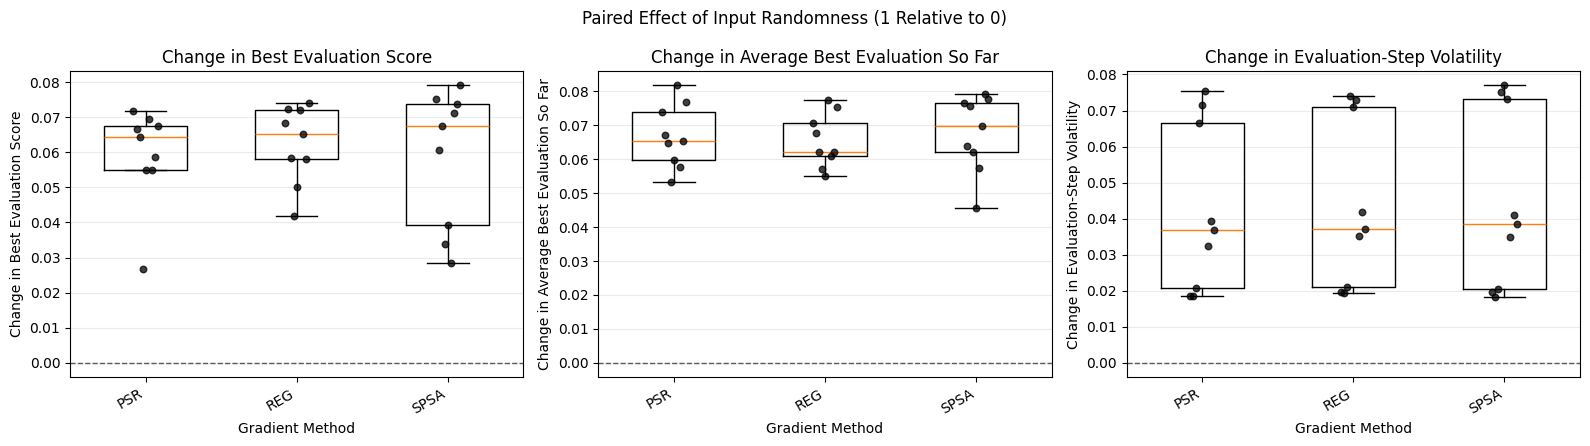

(<Figure size 1600x450 with 3 Axes>,
 array([<Axes: title={'center': 'Change in Best Evaluation Score'}, xlabel='Gradient Method', ylabel='Change in Best Evaluation Score'>,
        <Axes: title={'center': 'Change in Average Best Evaluation So Far'}, xlabel='Gradient Method', ylabel='Change in Average Best Evaluation So Far'>,
        <Axes: title={'center': 'Change in Evaluation-Step Volatility'}, xlabel='Gradient Method', ylabel='Change in Evaluation-Step Volatility'>],
       dtype=object))

In [17]:
RANDOMNESS_PAIR_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "eval_method": "gradient",
}
analysis.randomness_pairs(
    filters=RANDOMNESS_PAIR_FOCUS,
    baseline=0,
    treatment=1,
)

### 6. Scaling Analysis

Scaling is split into preset, execution type, gradient method, and randomness. Each subsection contains representative evaluation dynamics plus best-evaluation and average-best-so-far scaling across qubit counts. `SCALING_SCORE_TRANSFORM` controls only the learning dynamics-curve display: `none` retains raw scores, `normalize` maps each run to [0, 1] using its own minimum and maximum, and `standardize` applies a per-run z-score. Best-score summary panels always retain raw values. Parameter-count and circuit-width figures are intentionally reserved for the experimental-setup chapter.


#### 6.1 Scaling by preset

Noiseless PSR and `rand0` are fixed. Each preset is faceted to respect its evaluation metric; qubit count is the compared curve within each facet.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06a_preset_scaling_dynamics.png
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06b_preset_scaling_best_results.png


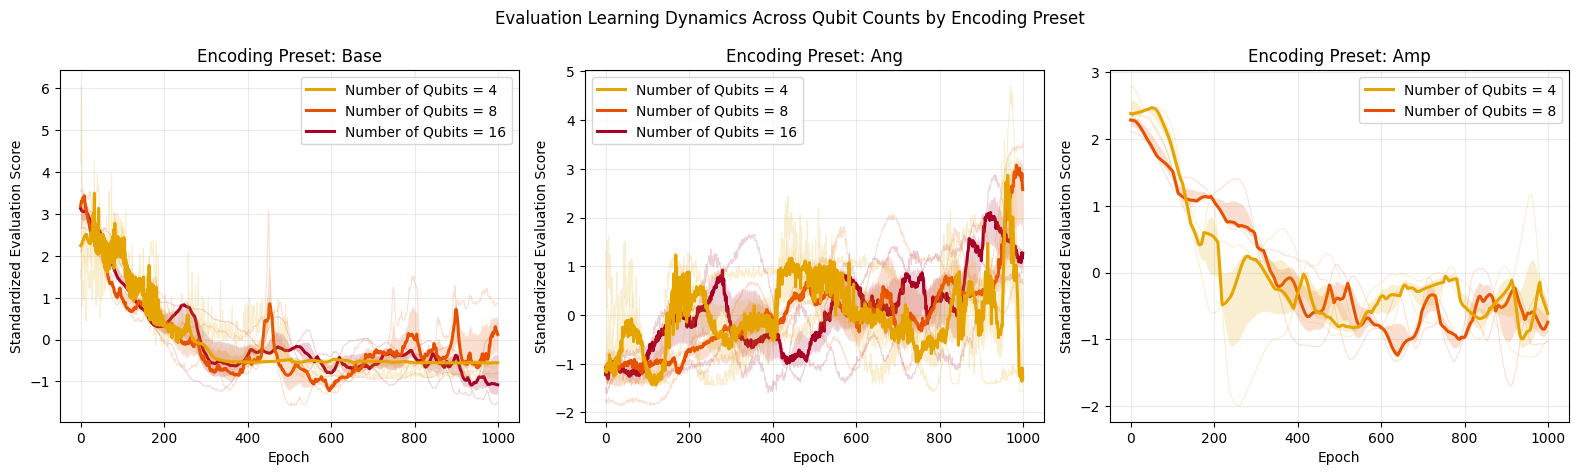

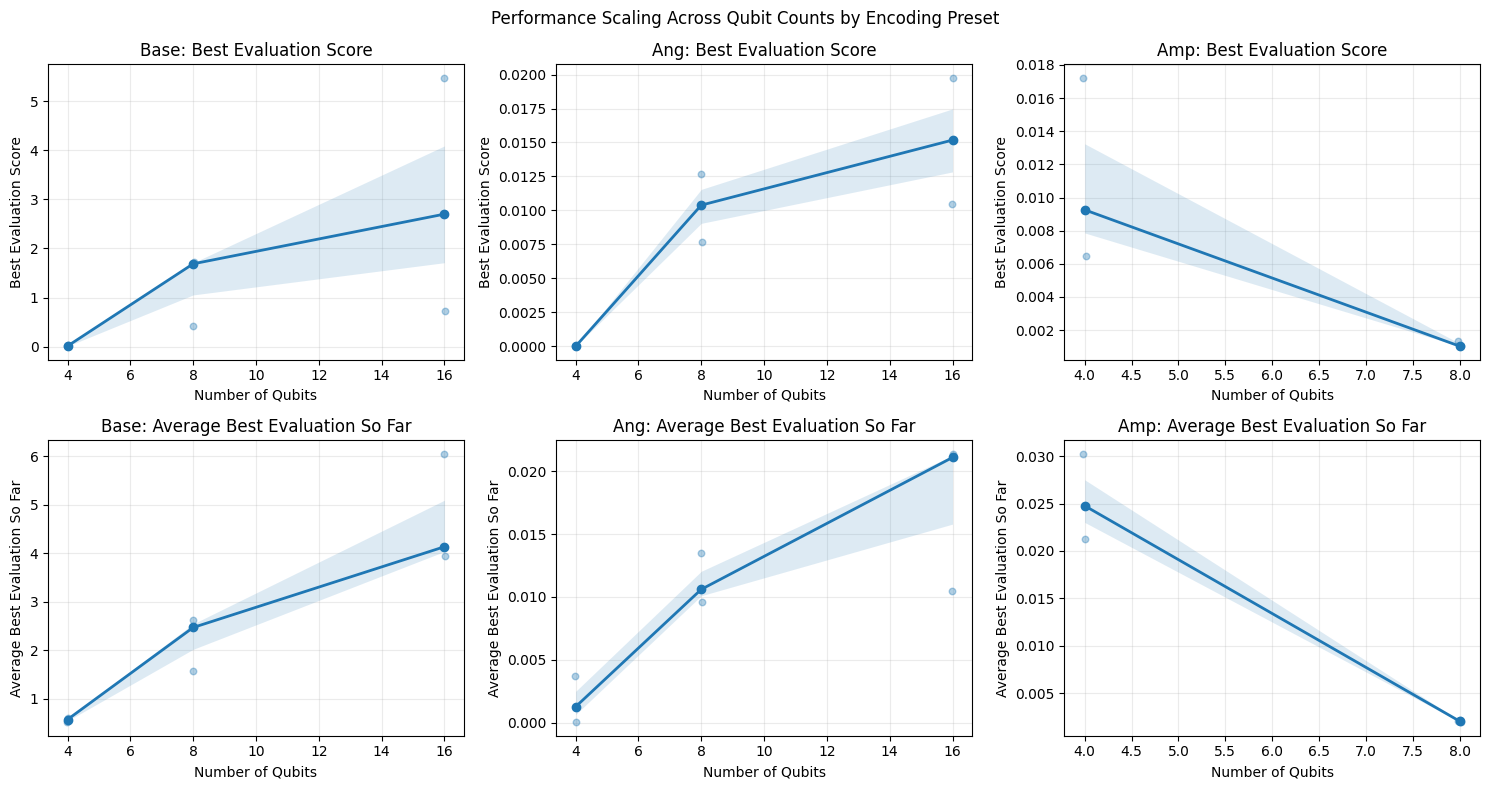

In [18]:
SCALING_SCORE_TRANSFORM = "standardize"  # "none", "normalize", or "standardize"

PRESET_SCALING_FOCUS = {
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "PSR",
    "randomness": 0,
}
preset_scaling_runs = analysis.preset_scaling(
    filters=PRESET_SCALING_FOCUS,
    presets=PRESET_ORDER,
    qubits_by_preset={"amp": (4, 8)},
    metric_transform=SCALING_SCORE_TRANSFORM,
)

#### 6.2 Scaling by execution type

The dynamics are split into noiseless and noisy panels for `ang`, SPSA, and `rand0`. Within each panel, curves compare the available qubit counts. No noisy `q16` result is inferred.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06c_execution_scaling_dynamics.png
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06d_execution_scaling_best_results.png


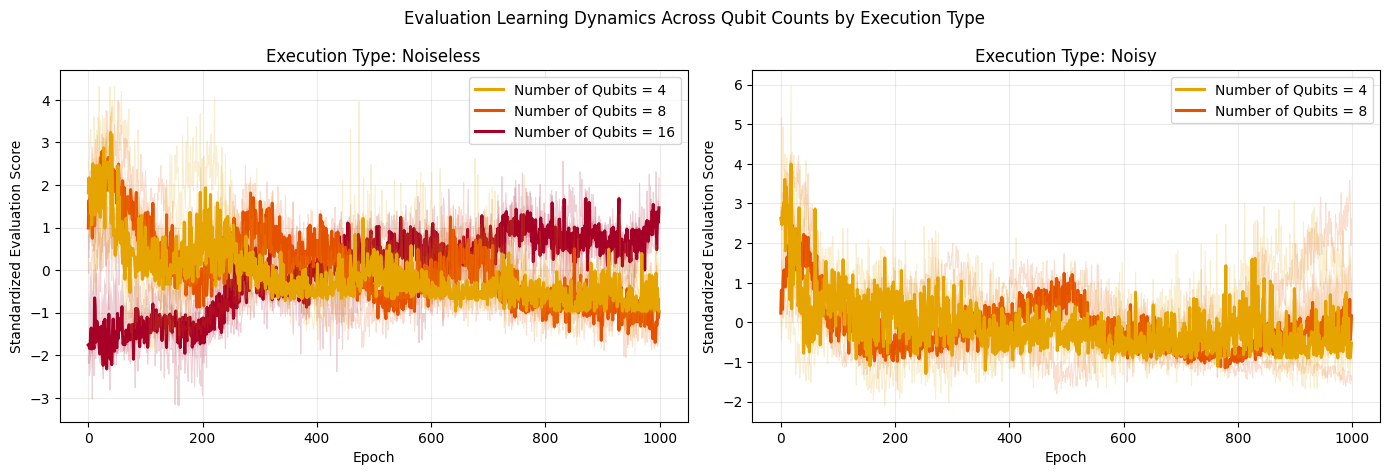

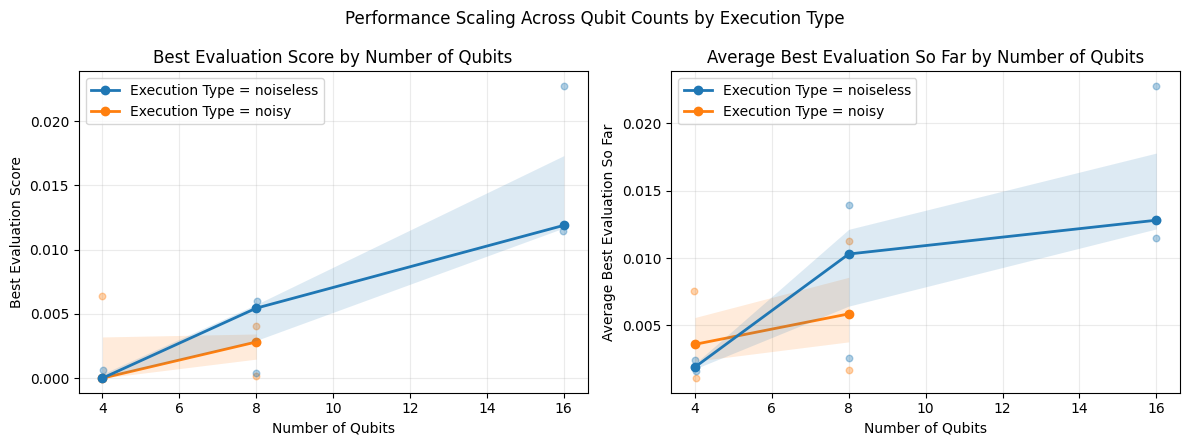

In [19]:
EXECUTION_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "gradient_method": "SPSA",
    "randomness": 0,
}
EXECUTION_TYPES = ("noiseless", "noisy")
execution_scaling_runs = analysis.execution_scaling(
    filters=EXECUTION_SCALING_FOCUS,
    execution_types=EXECUTION_TYPES,
    metric_transform=SCALING_SCORE_TRANSFORM,
)

#### 6.3 Scaling by gradient method

The dynamics are split into PSR, REG, and SPSA panels for `base`, noiseless execution, and `rand0`. Within each panel, curves compare the available qubit counts.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06e_gradient_scaling_dynamics.png
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06f_gradient_scaling_best_results.png


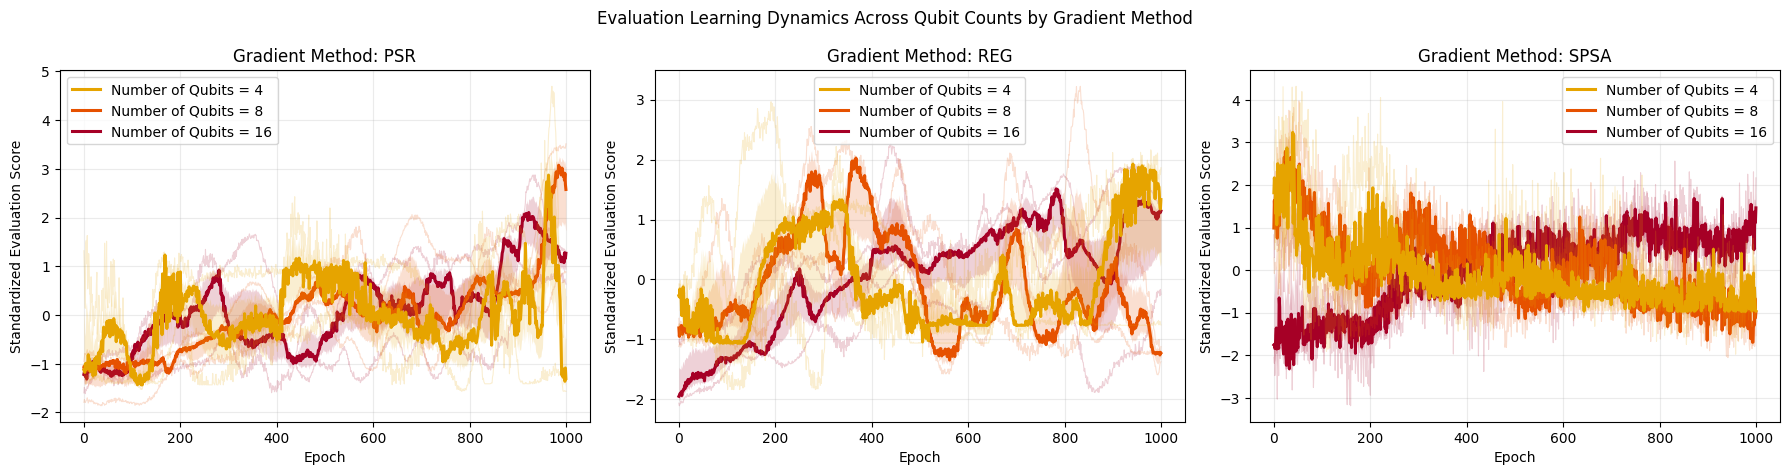

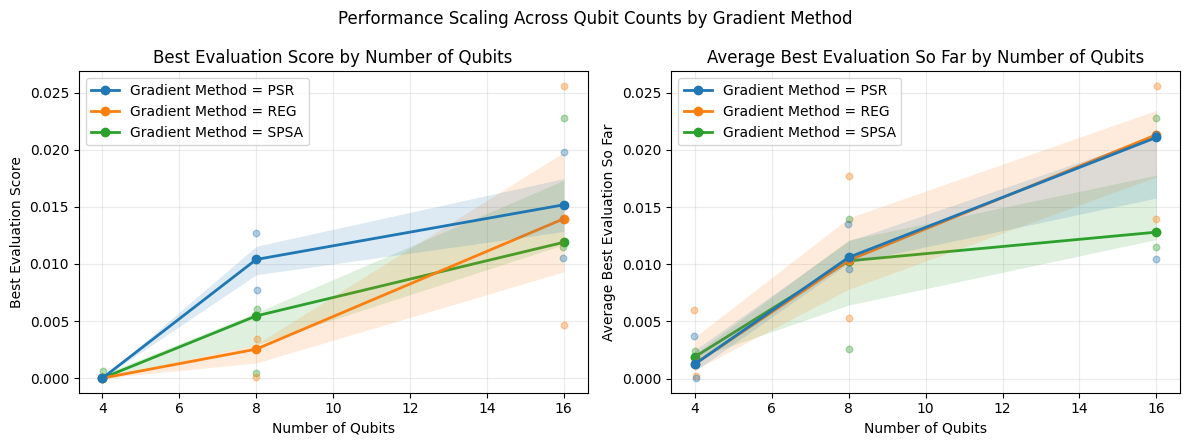

In [20]:
GRADIENT_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "randomness": 0,
}
gradient_scaling_runs = analysis.gradient_scaling(
    filters=GRADIENT_SCALING_FOCUS,
    gradient_methods=GRADIENT_ORDER,
    metric_transform=SCALING_SCORE_TRANSFORM,
)

#### 6.4 Scaling by randomness

The first figure compares q4 and q8 learning dynamics in separate panels for every value in the complete five-level randomness sweep. The following dynamics retain the focused `rand0` and `rand1` comparison for `ang`, noiseless PSR, followed by raw best-evaluation and average-best-so-far scaling. Within each dynamics panel, curves compare qubit counts. Use `SCALING_SCORE_TRANSFORM` from Section 6.1 to show raw, per-run normalized, or per-run standardized learning dynamics curves. Transformed curves compare trajectory shape; they must not be interpreted as absolute quality.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06g_randomness_complete_sweep_q4_q8_dynamics.png
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06h_randomness_scaling_dynamics.png
saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/06i_randomness_scaling_best_results.png


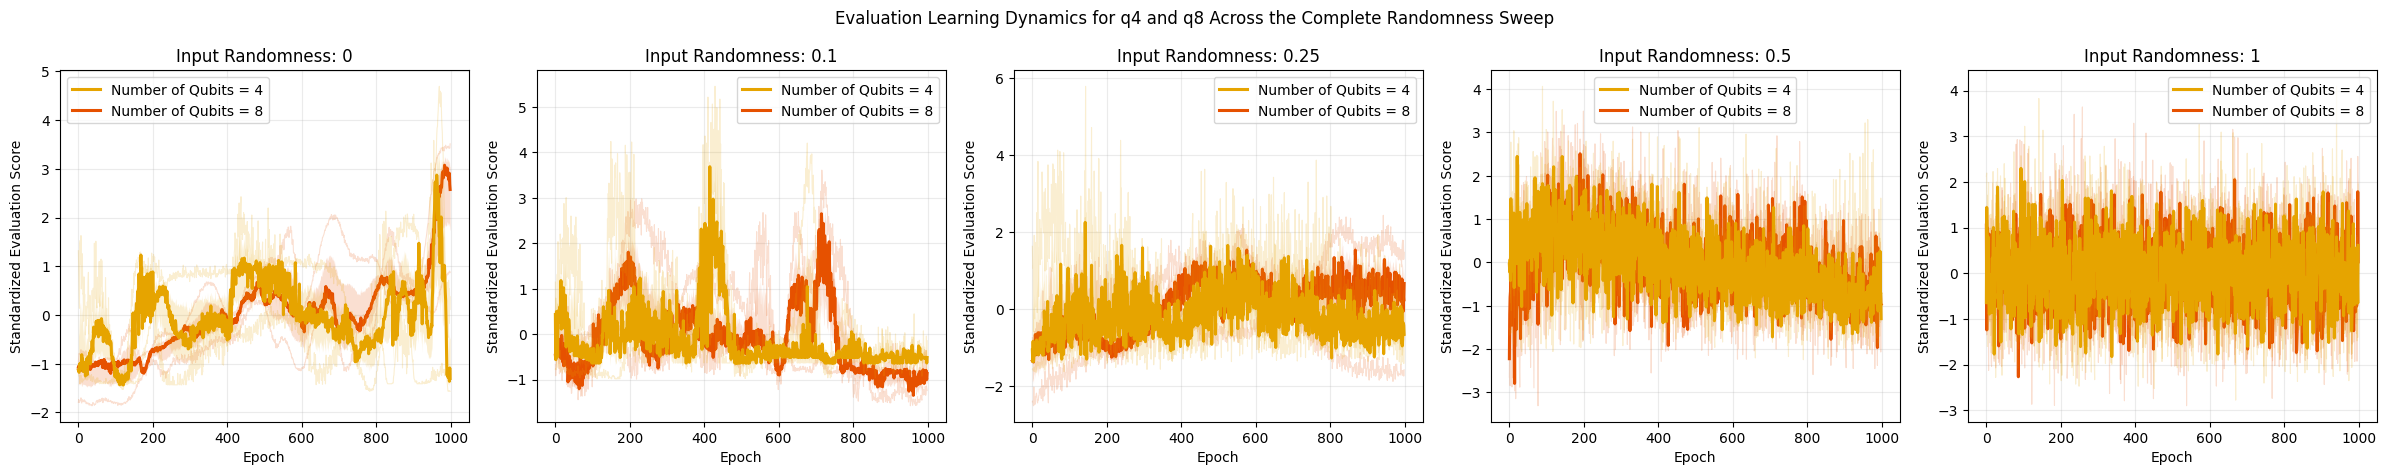

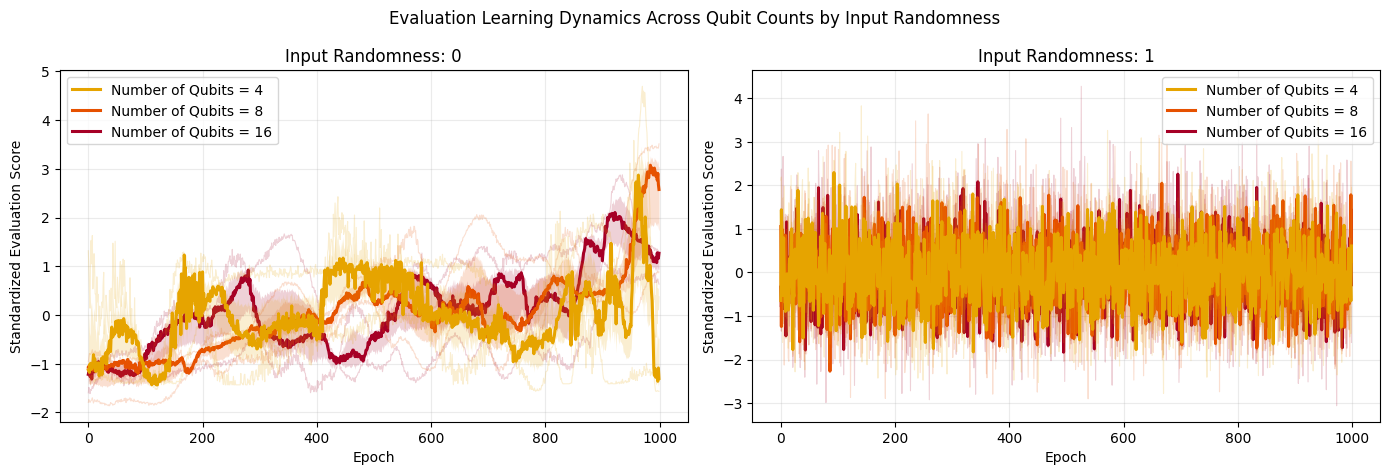

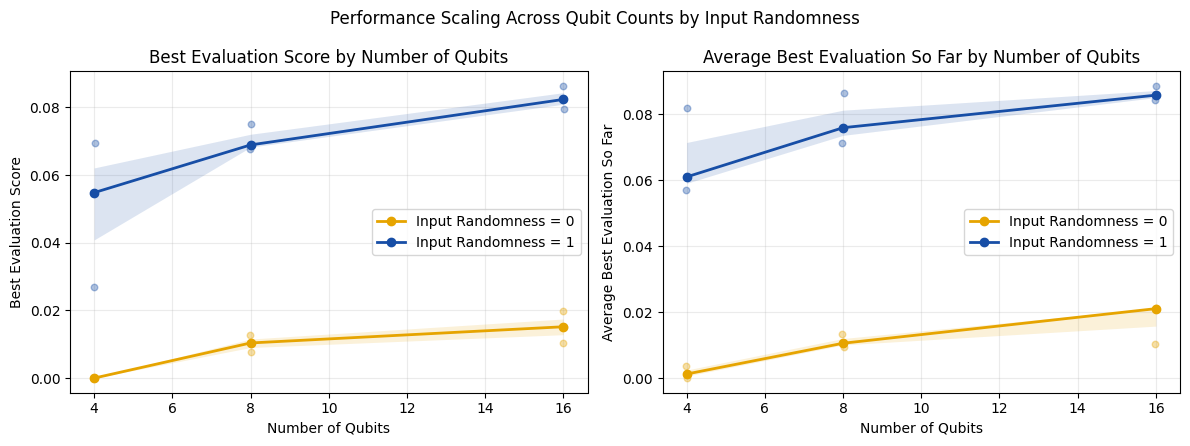

In [21]:
RANDOMNESS_SCALING_FOCUS = {
    "preset": "ang",
    "implementation": "qml_torch",
    "execution_type": "noiseless",
    "gradient_method": "PSR",
}
RANDOMNESS_SCALING_LEVELS = (0, 1)
RANDOMNESS_SCALING_SWEEP_LEVELS = RANDOMNESS_LEVELS
RANDOMNESS_SCALING_SWEEP_QUBITS = (4, 8)
randomness_scaling_runs = analysis.randomness_scaling(
    filters=RANDOMNESS_SCALING_FOCUS,
    randomness_levels=RANDOMNESS_SCALING_LEVELS,
    sweep_levels=RANDOMNESS_SCALING_SWEEP_LEVELS,
    sweep_qubits=RANDOMNESS_SCALING_SWEEP_QUBITS,
    metric_transform=SCALING_SCORE_TRANSFORM,
)

### 7. Implementation and Packing Validation

This final section only demonstrates that each implementation path trains. Fake-real `q4`, SPSA, `rand0`, seed-0 traces cover `qml_torch`, `runtime_packed/separate`, and valid `runtime_packed/joined` cases. No deep quality, timing, or statistical claim is made from one seed.


saved: /home/benat/Qiskit-IBM/qgan/figures/results_analysis/07_implementation_packing_validation.png


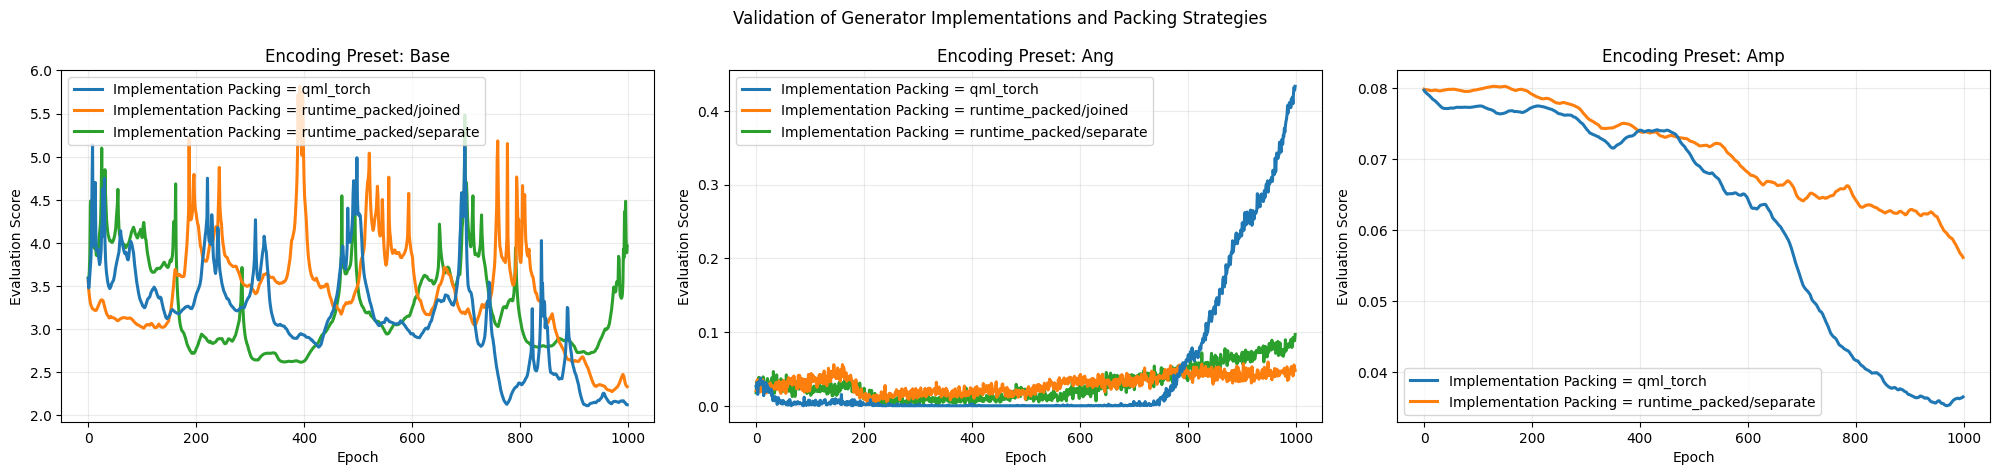

| Run Id | Preset | Implementation Packing | Completed Epochs | Best Eval | Average Best So Far Eval |
| --- | --- | --- | --- | --- | --- |
| amp-qml_torch-q4-fake_real-SPSA-aerCPU-rand0-seed0 | amp | qml_torch | 1000 | 0.0352 | 0.06221 |
| amp-runtime_packed-separate-q4-fake_real-SPSA-aerCPU-rand0-seed0 | amp | runtime_packed/separate | 1000 | 0.05608 | 0.07091 |
| ang-qml_torch-q4-fake_real-SPSA-aerCPU-rand0-seed0 | ang | qml_torch | 1000 | -0 | 0.0005691 |
| ang-runtime_packed-joined-q4-fake_real-SPSA-aerCPU-rand0-seed0 | ang | runtime_packed/joined | 1000 | 0.002163 | 0.005125 |
| ang-runtime_packed-separate-q4-fake_real-SPSA-aerCPU-rand0-seed0 | ang | runtime_packed/separate | 1000 | 0.001649 | 0.004251 |
| base-qml_torch-q4-fake_real-SPSA-aerCPU-rand0-seed0 | base | qml_torch | 1000 | 2.113 | 2.798 |
| base-runtime_packed-joined-q4-fake_real-SPSA-aerCPU-rand0-seed0 | base | runtime_packed/joined | 1000 | 2.278 | 2.956 |
| base-runtime_packed-separate-q4-fake_real-SPSA-aerCPU-rand0-seed0 | base | runtime_packed/separate | 1000 | 2.617 | 2.799 |

In [22]:
VALIDATION_FOCUS = {
    "execution_type": "fake_real",
    "n_qubits": 4,
    "gradient_method": "SPSA",
    "randomness": 0,
    "seed": 0,
}
fake_validation = analysis.implementation_validation(
    filters=VALIDATION_FOCUS,
    presets=PRESET_ORDER,
)